# 设置

In [1]:
# 定义默认字体大小，让图表看起来更美观：
import matplotlib as mpl  # 导入matplotlib库
import matplotlib.pyplot as plt  # 导入matplotlib.pyplot库

mpl.rcParams.update(mpl.rcParamsDefault)  # 重置matplotlib的配置参数为默认值
plt.style.use('default')  # 使用默认的绘图风格

# 设置全局字体大小为14
plt.rc('font', size=14)
# 设置坐标轴标签和标题的字体大小为14
plt.rc('axes', labelsize=14, titlesize=14)
# 设置图例的字体大小为14
plt.rc('legend', fontsize=14)
# 设置x轴刻度标签的字体大小为10
plt.rc('xtick', labelsize=10)
# 设置y轴刻度标签的字体大小为10
plt.rc('ytick', labelsize=10)

In [2]:
# 创建一个名为 `images/classification` 的文件夹（如果该文件夹尚不存在），并定义 `save_fig()` 函数，用于保存图片
from pathlib import Path

IMAGES_PATH = Path() / "images" / "classification"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# 第三章——分类

1. MNIST
2. 训练二元分类器

## 1. MNIST

MNIST数据集是由高中生和美国人口普查局的员工手写的70000个数字图像。每个图象都标有它代表的数字。

它通常呗称为机器学习的“hello world”

`Scikit-Learn`提供了许多帮助函数来下载流行的数据集。

`sklearn.datasets`包主要包含三种类型的函数：
1. `fetch_*`函数(例如`fetch_openml()`)用来下载现实生活中的数据集。作为`sklearn.utils.Bunch`对象返回。
2. `load_*`函数(例如`load_iris()`)用来加载与`Scikit-Learn`捆绑的小玩具数据集(因为它们不需要通过互联网下载)。作为`sklearn.utils.Bunch`对象返回。
3. `make_*`函数用来生成假数据，对测试很有用。生成的数据通常作为包含输入数据和目标的(X, y)元组返回，两者都是Numpy数组

`Bunch`对象是字典，其条目也可以作为属性返回，通常包含以下条目：
* `"DESCR"`: 数据集的描述。
* `"data"`: 输入数据，通常为二维Numpy数组。
* `"target"`: 标签，通常是一维Numpy数组。

In [3]:
# 找到当前环境下的缓存路径
from sklearn.datasets import get_data_home

print(get_data_home())

C:\Users\www12\scikit_learn_data


In [4]:
# 从OpenML.org获取MNIST数据集
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False,
                     data_home='F:\mywork\Hands-On Machine Learning\my-study\datasets\scikit_learn_data') # 显式修改指定缓存目录

---

补充：
1. 什么是`Bunch`对象？
    * Bunch是一个“**支持属性访问的字典**”，即1.Bunch是一个key-value容器；2.既可以像字典(`obj['data']`)一样访问；3.也可以像对象属性(`obj.data`)一样访问。（如下代码）
    * Bunch的本质是`dict`的子类，源码如下

    ```
    class Bunch(dict):
        def __init__(self, **kwargs):
            super().__init__(kwargs)
            self.__dict__ = self
    ```

   * 关键在于`self.__dict__ = self`，它使得`obj.data`等价于`obj['data']`
   * Bunch对象不强调行为(methods)，只强调**数据+元信息(意为理解数据的数据)+说明文档**的结构化封装
    * Bunch里面装着`ndarray`，而不是`DataFrame`，因为它不继承`Pandas`，它是一个轻量的数据集容器，它设计为`Numpy`原生类型

In [5]:
from sklearn.datasets import load_iris # 加载鸢尾花数据集，150个样本，每个样本4个特征，目标变量是3种鸢尾花的类别

iris = load_iris() # 此时iris为一个bunch对象
print(type(iris)) # sklearn.utils._bunch.Bunch

# 可以用两种方式访问数据，两种方式等价
iris['data']

<class 'sklearn.utils._bunch.Bunch'>


array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [6]:
iris.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [7]:
iris.keys() # 列出bunch对象里的所有字段名

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [8]:
iris.DESCR # 元信息，即数据集的描述

'.. _iris_dataset:\n\nIris plants dataset\n--------------------\n\n**Data Set Characteristics:**\n\n:Number of Instances: 150 (50 in each of three classes)\n:Number of Attributes: 4 numeric, predictive attributes and the class\n:Attribute Information:\n    - sepal length in cm\n    - sepal width in cm\n    - petal length in cm\n    - petal width in cm\n    - class:\n            - Iris-Setosa\n            - Iris-Versicolour\n            - Iris-Virginica\n\n:Summary Statistics:\n\n============== ==== ==== ======= ===== ====================\n                Min  Max   Mean    SD   Class Correlation\n============== ==== ==== ======= ===== ====================\nsepal length:   4.3  7.9   5.84   0.83    0.7826\nsepal width:    2.0  4.4   3.05   0.43   -0.4194\npetal length:   1.0  6.9   3.76   1.76    0.9490  (high!)\npetal width:    0.1  2.5   1.20   0.76    0.9565  (high!)\n============== ==== ==== ======= ===== ====================\n\n:Missing Attribute Values: None\n:Class Distribution: 

2. `fetch_openml()`有些特殊，它默认情况下是以`Pandas DataFrame`的形式返回输入，以`Pandas Series`的形式返回标签（除非数据集是稀疏的）。但是MNIST数据集包含图像，所以设置`as_frame=False`来获取Numpy数组形式的数据。

In [9]:
# 当as_frame=True时的输入返回示例
mnist_frame = fetch_openml('mnist_784', as_frame=True,
                     data_home='F:\mywork\Hands-On Machine Learning\my-study\datasets\scikit_learn_data')

In [10]:
type(mnist_frame)

sklearn.utils._bunch.Bunch

In [11]:
type(mnist_frame.data)

pandas.core.frame.DataFrame

In [12]:
type(mnist_frame.target)

pandas.core.series.Series

In [13]:
type(mnist)

sklearn.utils._bunch.Bunch

In [14]:
type(mnist.data)

numpy.ndarray

In [15]:
type(mnist.target)

numpy.ndarray

---

看一下MNIST数据集中的data和target

In [16]:
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [17]:
X, y = mnist.data, mnist.target

In [18]:
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [19]:
X.shape

(70000, 784)

In [20]:
y

array(['5', '0', '4', ..., '4', '5', '6'], dtype=object)

In [21]:
y.shape

(70000,)

可以看到有70000张图片，每张图片有784个特征。因为每个图像都是28×28像素，每个特征只代表一个像素的强度（从0（白色）到255（黑色））

看看数据集中的一个数字图片。需要获取一个实例的特征向量，将其变为28×28的数组，并使用Matplotlib的`imshow()`函数。使用`cmap=binary`来获得灰度颜色图。

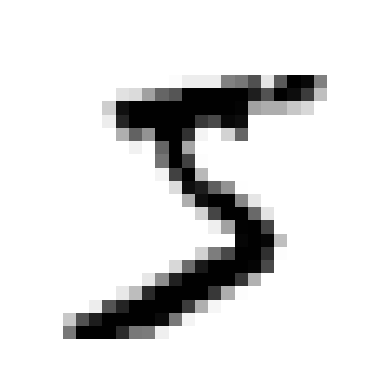

In [22]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
    image = image_data.reshape(28, 28)  # 一维向量 → 图像
    plt.imshow(image, cmap="binary")    # 用黑白色映射显示
    plt.axis("off")                     # 去掉无意义的坐标轴

some_digit = X[0]
plot_digit(some_digit)
plt.show()

---

补充：
1. cmap 是 colormap（颜色映射） 的缩写，用来规定：如何把“数值”映射成“颜色”
2. "binary"是黑白灰渐变色图。数值小 → 白色；数值大 → 黑色；中间值 → 灰度渐变
3. “binary”是“gray”的颜色相反操作（可尝试一下）
4. plt.axis() 用于控制：坐标轴显示范围与坐标轴是否可见。“off”为关闭坐标轴的所有可视元素

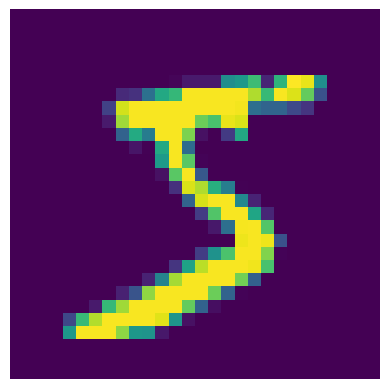

In [23]:
def plot_digit_grey(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="viridis")
    plt.axis("off")

some_digit = X[0]
plot_digit_grey(some_digit)
plt.show()

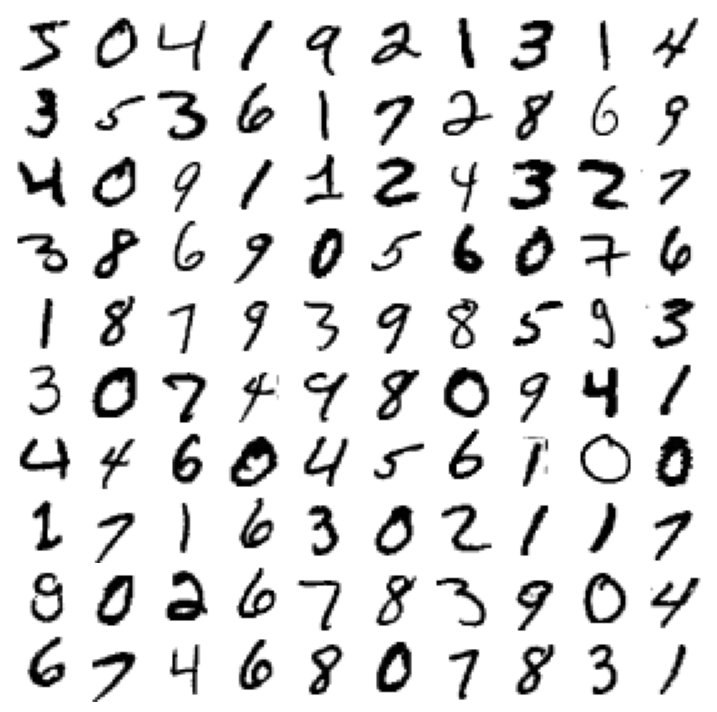

In [24]:
# 看看更多图像
plt.figure(figsize=(9, 9))
for idx, image_data in enumerate(X[:100]):
    plt.subplot(10, 10, idx + 1)
    plot_digit(image_data)
plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

**创建一个测试集**

`fetch_openml()`返回得MNIST数据集实际上已经是拆分为训练集（前60000个图像）和测试集（后10000个图像）

In [25]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

训练集已经在设计时就打乱了，这样保证了所有交叉验证折叠都是相似的。而且一些学习算法对训练实例的顺序很敏感，如果连续获得许多相似的实例，它们的性能就会很差（这句话不适用于时间序列数据）

## 2. 训练二元分类器

简化问题：只尝试识别一个数字————例如：识别数字5，二元分类四能够区分两个类：5和非5

In [26]:
# 首先，创建目标向量
y_train_5 = (y_train == '5') # 对于数字5，结果为真；对于其他数字，结果为假。
y_test_5 = (y_test == '5')

In [27]:
y_train_5 # True为‘5’；False为‘非5’

array([ True, False, False, ...,  True, False, False])

选择一个分类器并对其进行训练， 一个好的起点是使用Scikit-Learn的随机梯度下降（Stochastic Gradient Descent, SGD，或随机GD）分类器`SGDClassifier`类。该分类器能够有效地处理非常大的数据集。因为SGD独立处理训练实例，一次一个，这也使得SGD非常适合在线学习。

In [28]:
# 创建一个SGDClassifier并在整个训练集上训练
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

SGDClassifier(random_state=42)

In [29]:
# 检测数字5的图像
sgd_clf.predict([X[35]])

array([ True])

## 3. 性能测量

### 3.1. 使用交叉验证测量精度

1. 精度并不是分类任务的首选性能指标

使用`cross_val_score()`函数评估SGDClassifier模型， 使用3个折叠的k折交叉验证(即将训练集分成3个不同的子集（折叠），然后对模型进行k次训练，每次使用不同的折叠进行评估)

In [30]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

看一种**虚构分类器(DummyClassifier)**，它只对数据集中出现最多类别进行预测，也就说是永远预测训练集中出现次数最多的标签，例如：在MNIST数据集中对于‘非5’类别要比‘5’类别多得多，此时‘非5’为阴性类，所以“不管输入是什么，都判断它为‘非5’。”

DummyClassifier 的意义不在于“预测对了什么”，而在于告诉你：在不看任何特征的情况下，光靠标签分布，模型最多能做到什么水平。只有显著超过它的模型，才是真正“学到了东西”的模型。

这个“最蠢的模型”，其实是你最重要的老师之一。

In [31]:
# 构建虚构分类器 DummyClassifier
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
print(dummy_clf.predict(X_train)) # 全是False
print(any(dummy_clf.predict(X_train))) # False

[False False False ... False False False]
False


In [32]:
# 看看DummyClassifier的k折交叉验证结果
cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.90965, 0.90965, 0.90965])

`array([0.90965, 0.90965, 0.90965])`结果说明了最笨的模型在5与非5预测上也有90以上的准确率。

这说明了为什么精度通常不是分类器的首选性能指标。尤其是**处理不平衡的数据集时（即当某些类比其他类出现更频繁时）**。

评估分类器性能的更好方法时查看混淆矩阵（Confusion Matrix, CM）

有时，需要自己**实现交叉验证工程**，可以比`Scikit-Learn`提供的现成工具有更多的控制过程的能力。

In [33]:
# 实现与cross_val_score()函数大致相同的过程
from sklearn.model_selection import StratifiedKFold # 分层分组K折交叉验证
from sklearn.base import clone # 用于复制一个“未训练状态”的模型，保留超参数，但清空所有已学习的参数。

skfolds = StratifiedKFold(n_splits=3) # 如果数据集不存在，则添加 shuffle=True

for train_index, test_index in skfolds.split(X_train, y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train[train_index]
    y_train_folds = y_train_5[train_index]
    X_test_folds = X_train[test_index]
    y_test_folds = y_train_5[test_index]

    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_folds)
    n_correct = sum(y_pred == y_test_folds)
    print(n_correct / len(y_pred))

0.95035
0.96035
0.9604


1. `StratifiedGroupKFold`(分层K折交叉验证)是一种交叉验证**划分器**，在每一折中，保持标签 y 的类别比例与整体尽量一致
2. `clone` 用于复制一个“未训练状态”的模型，保留超参数，但清空所有已学习的参数。
3. `n_splits=5` 表示把组（不是单个样本）分配到 5 个折中，然后迭代 5 次：
    * 第 1 次：fold1 做 test，其余 fold2-5 做 train
    * 第 2 次：fold2 做 test，其余做 trainz
    * …
    * 第 5 次：fold5 做 test，其余做 train

    因此会得到 5 组 (train_idx, test_idx)。且这只是声明，切分在`.split()`做


## 3.2. 混淆矩阵

混淆矩阵的一般思想是：计算所有 A/B 对的 A 类实例被分类为 B 类的次数。（即对每一种（真实类别，预测类别）的组合，统计真实属于该类别的样本，被模型预测成另一类别的数量）。比如下述为一个混淆矩阵，一共 4 种(两种真实情况 × 两种判断结果) A/B 对：1. 真实是苹果，被判成苹果；2. 真实是苹果，被判成不是苹果；3. 真实不是苹果，被判成苹果；4. 真实不是苹果，被判成不是苹果。混淆矩阵结果为

| 真实 \ 判断 | 苹果 | 不是苹果 |
| ------- | -- | ---- |
| 苹果      | 3  | 2    |
| 不是苹果    | 2  | 3    |

混淆矩阵中**每一行代表一个实际类，而每一列代表一个预测类**。

要计算混淆矩阵，首先需要有一组预测值，以便可以将它们与实际目标进行比较。可以对测试集进行预测，但最好暂时保持不变（需记住：**一旦有一个准备好启动的分类器，只在项目的最后才使用测试集**）。作为替代，可以使用`cross_val_predict()`函数。

* `cross_val_predict()`像`cross_val_score()`函数那样，它执行k折交叉验证，但是不返回评估分数，而是返回对每个测试折进行的预测。这意味着对训练集中的每个实例都能得到一份干净的预测（“干净”指“样本外”：即模型对它在训练期间从未见过的数据进行预测）
* `cross_val_predict` 不会复用你已经 fit 过的模型，它会在内部：clone 一个新的模型，并在每一折中重新 fit。因为交叉验证要求：
每一折的模型必须是“在该折训练集上、从零开始训练的独立模型”。

In [34]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

In [35]:
y_train_pred # 返回是布尔值，因为y_train_5是布尔值

array([ True, False, False, ...,  True, False, False])

In [36]:
# 使用混淆矩阵，只需将目标类（y_train_5）和预测类（y_train_pred）传给它
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_train_5, y_train_pred)
cm

array([[53892,   687],
       [ 1891,  3530]])

`confusion_matrix` 默认按“标签的排序顺序”来排，而 False（0） < True（1）。

上述混淆矩阵的第一行考虑非5图像（阴性类）：其中有53892张被正确分类为非5（称为真阴性），而其余687张被错误分类为5（假阴性，也称为**Ⅰ类错误**）；第二行考虑5图像（阳性类）：其中有1891张被错误分类为非5（假阴性，也称为**Ⅱ类错误**），而其余3530张被正确分类为5（真阴性）。

一个**完美**的分类器只会有真阳性和真阴性，所以它的混淆矩阵**只会**在它的主对角线上有非0值

In [37]:
# 一个完美的分类器的混淆矩阵
y_train_perfect_predictions = y_train_5

confusion_matrix(y_train_5, y_train_perfect_predictions)

array([[54579,     0],
       [    0,  5421]])

* 阳性（positive）：你“关心、要检测、要识别”的那一类
* 阴性（negative）：除阳性以外的其他类
---
* TP = True Positive（真正例 / 真阳性）：真实阳性，预测也是阳性
* TN = True Negative（真反例 / 真阴性）：真实是阴性 ，但预测成了阴性
* FP = False Positive（假正例 / 假阳性）：真实是阴性，但预测成了阳性
* FN = False Negative（假反例 / 假阴性）：真实是阳性，预测也是阴性

True / False：表示预测对不对；Positive / Negative：表示你定义的正类/负类（阳性/阴性）

| **实际 \ 预测**         | **预测为阳性（Positive）**                    | **预测为阴性（Negative）**                    |
| ------------------- | -------------------------------------- | -------------------------------------- |
| **实际为阳性（Positive）** | **TP**（True Positive）<br>真实是阳性，预测也是阳性  | **FN**（False Negative）<br>真实是阳性，但预测成阴性 |
| **实际为阴性（Negative）** | **FP**（False Positive）<br>真实是阴性，但预测成阳性 | **TN**（True Negative）<br>真实是阴性，预测也是阴性  |


一个指标是**阳性预测的精度**（称为分类器的精确率（预测为正的结果有多准确））：

$$
\text{精确率} = \frac{TP}{TP + FP}
$$

分类器的准确率指标（整体预测有多准确）：

$$
\text{准确率} = \frac{TP + TN}{TP + TN + FP + FN}
$$

获得完美精确率的一种简单方法是创建一个始终做出阴性预测的分类器，只对它最有信心的一个实例做出阳性预测。此时，TP为1（真实为阳性，预测也为阳性），FP为0（真实为阴性，预测为阳性），那么分类器就有100%精确率。显然，这种分类器不会很有用，因为它忽略了除一个阳性实例之外的所有实例。因此，准确率通常与另一个名为**召回率**的指标一起使用，召回率也称为**灵敏度或真阳性率(True Positive Rate, TPR)**：这是分类器正确检测到的阳性实例的比率，也即**在所有“真实为阳性”的样本中，分类器成功找回了多少。**

$$
\text{召回率} = \frac{TP}{TP + FN}
$$

如果精确率偏低，说明FP高，即真实为阴性，大多预测为阳性（错的弄对了）；如果召回率偏低，说明FN高，即真实为阳性，大多预测为阴性（对的弄错了）。

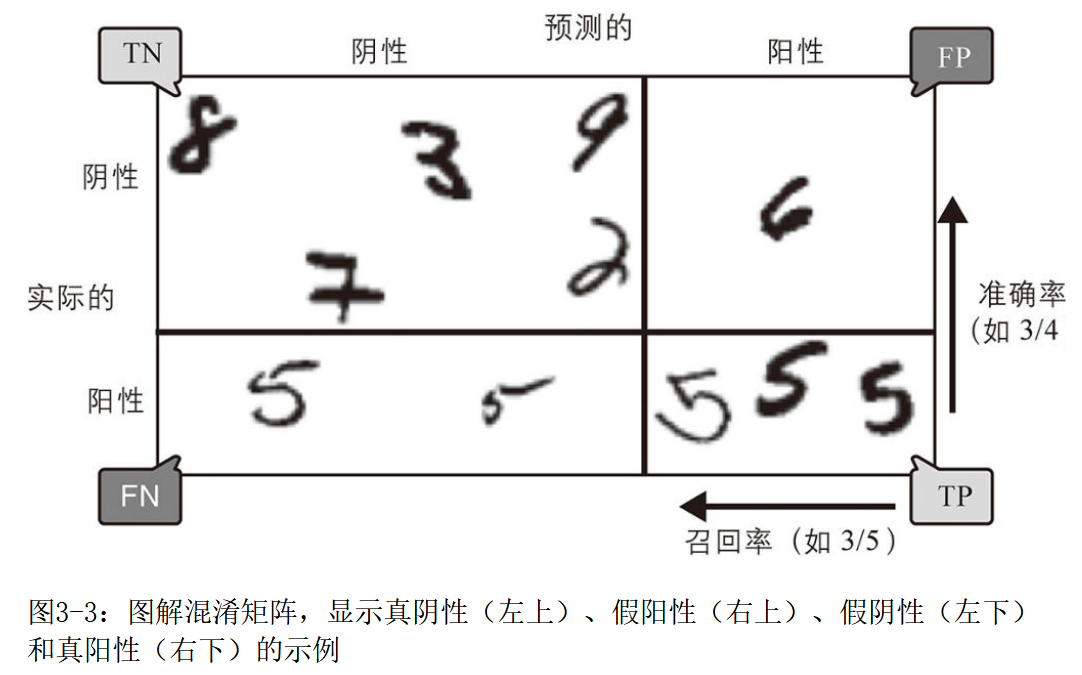

## 3.3. 精确率和召回率

In [38]:
# Scikit-Learn提供了几个函数来计算分类器指标，包括精确率和召回率
from sklearn.metrics import precision_score, recall_score

precision_score(y_train_5, y_train_pred)

0.8370879772350012

In [39]:
# 在表格上计算精确率
cm[1, 1] / (cm[0, 1] + cm[1, 1])

np.float64(0.8370879772350012)

In [40]:
recall_score(y_train_5, y_train_pred)

0.6511713705958311

In [41]:
# 在表格上计算召回率
cm[1, 1] / (cm[1, 0] + cm[1, 1])

np.float64(0.6511713705958311)

可看到精确率仅有83%，对于分类任务并不能看其精度。

将精确率和召回率组合成一个称为$F_1$分数的指标通常很方便，尤其是当你需要一个指标来比较两个分类器时。

$F_1$分数是精确率和召回率的**调和均值**。常规均值对所有均值一视同仁，而调和均值则为低值赋予更多权重。因此，如果召回率和精确率都很高，那么分类器会获得较高的$F_1$分数。公式如下：

$$
F_1 \text{ 分数}
= \frac{2}{\dfrac{1}{\text{准确率}} + \dfrac{1}{\text{召回率}}}
= 2 \times \frac{\text{准确率} \times \text{召回率}}{\text{准确率} + \text{召回率}}
= \frac{TP}{TP + \dfrac{FN + FP}{2}}
$$

$F_1$设计目标是：用一个数，同时衡量 Precision 和 Recall，并且不允许其中任何一个“被忽略”。而算术平均不能惩罚一头差的情况，所以用调和平均。

In [42]:
# 调用f1_score()函数可计算f1分数
from sklearn.metrics import f1_score

f1_score(y_train_5, y_train_pred)

0.7325171197343847

In [43]:
# 在表格上计算f1分数
cm[1, 1] / (cm[1, 1] + (cm[1, 0] + cm[0, 1]) / 2)

np.float64(0.7325171197343847)

$F_1$分数有利于具有相似准确率和召回率的分类器。这并不总是想要的：在某些情况下主要关心准确率，而在其他情况下真正关心召回率。
* 例1：如果训练了一个分类器来检测对孩子安全的视频（主要是让孩子看不到不安全的视频），反映的关键结果是高精确率（不安全的视频可以被检测出来），此时，低召回率也是很好的选择（安全的视频也被检测为不安全的视频）。
* 例2：如果训练了一个分类器检测监控图像中的小偷：如果分类器只有30%的精确率（正常人也被检测为小偷），有99%的召回率（所有的小偷大都被正确识别），这样也没问题。

不幸的是，不能两者兼顾：提高准确率会降低召回率，反之亦然。这称为**精确率召回率权衡**


## 3.4. 精确率/召回率权衡


* 当阈值调高（更保守）：误报低(FP低)->精确率高；漏报高(FN高)->召回率低
* 当阈值调低（更激进）：漏报低(FN低)->召回率高；误报高(FP高)->精确率低

`Scikit-Learn`不允许直接设置阈值，但可以访问用于预测的决策分数。可以调用它的`decision_function()`方法，而不是调用分类器的`predict()`方法，该方法返回每个实例的分数，然后根据这些分数使用想要的任何阈值进行预测：

`decision_function()`返回的是：分类器对“样本属于正类的信心分数（连续值）”，而不是最终的类别标签。分数 > 0：倾向于正类；分数 < 0：倾向于负类；绝对值越大：模型越“自信”

In [44]:
y_scores = sgd_clf.decision_function([X[0]])
y_scores

array([2164.22030239])

In [45]:
threshold = 0
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([ True])

In [46]:
# 提高阈值
threshold = 3000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False])

这证实了提高阈值会降低召回率。

如何决定使用哪个阈值？首先，使用cross_val_predict()函数获取训练集中的所有实例的分数，但这次指定要返回决策分数而不是预测：

In [47]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3,
                             method="decision_function")
y_scores

array([  1200.93051237, -26883.79202424, -33072.03475406, ...,
        13272.12718981,  -7258.47203373, -16877.50840447])

有了这些分数，使用`precision_recall_curve()`函数计算所有可能的阈值的准确率和召回率（该函数添加最后一个为1的精确率和最后一个为0的召回率，对应于无限阈值）：

`precision_recall_curve()` 会将模型输出的决策分数去重并排序，依次作为候选阈值，在每个阈值下计算对应的 Precision 和 Recall，从而刻画阈值变化对分类性能的影响。

In [48]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

In [49]:
precisions

array([0.09035   , 0.09035151, 0.09035301, ..., 1.        , 1.        ,
       1.        ])

In [50]:
recalls

array([1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
       3.68935621e-04, 1.84467810e-04, 0.00000000e+00])

In [51]:
thresholds

array([-146348.56726174, -142300.00705404, -137588.97581744, ...,
         38871.26391927,   42216.05562787,   49441.43765905])

最后，使用`Matplotlib`绘制作为阈值函数的精确率和召回率。

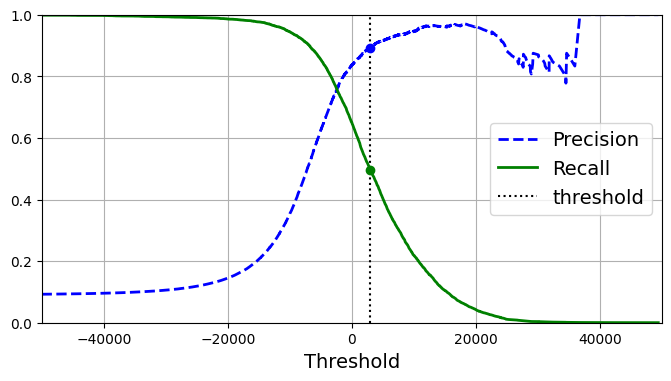

In [52]:
# 选择3000的阈值
plt.figure(figsize=(8, 4))  # extra code – it's not needed, just formatting
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(threshold, 0, 1.0, "k", "dotted", label="threshold")

# extra code – this section just beautifies and saves Figure 3–5
idx = (thresholds >= threshold).argmax()  # first index ≥ threshold
plt.plot(thresholds[idx], precisions[idx], "bo")
plt.plot(thresholds[idx], recalls[idx], "go")
plt.axis([-50000, 50000, 0, 1])
plt.grid()
plt.xlabel("Threshold")
plt.legend(loc="center right")

plt.show()

为什么随着阈值的增加精确率有时会有下降呢？
* 因为随着阈值的增大，预测为阳性的样本中真阳性可能被优先移除，而假阳性减少得较慢，从而导致假阳性在预测阳性中的比例上升，进而使精确率下降。

在固定模型和数据集条件下，决策阈值越高，判为阳性的标准越严格，真阳性数不会增加、假阴性数不会减少，因此召回率只能保持不变或下降。

当阈值为3000时，精确率大约为90%，召回率大约为50%。选择一个好的精确率/召回率权衡的另一种方法是直接绘制精确率与召回率的关系图：

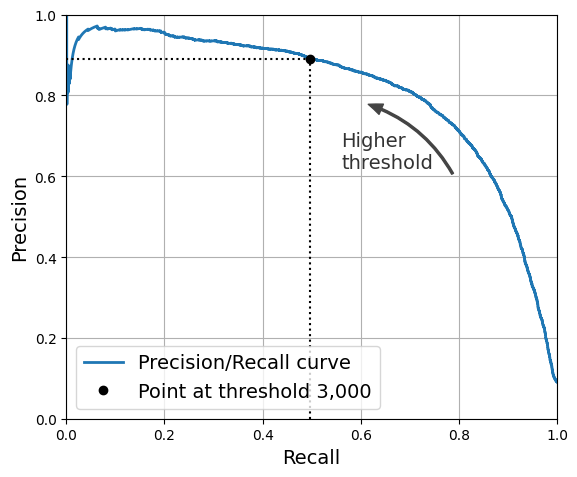

In [53]:
import matplotlib.patches as patches  # extra code – for the curved arrow

plt.figure(figsize=(6, 5))  # extra code – not needed, just formatting

plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve")

# extra code – just beautifies and saves Figure 3–6
plt.plot([recalls[idx], recalls[idx]], [0., precisions[idx]], "k:")
plt.plot([0.0, recalls[idx]], [precisions[idx], precisions[idx]], "k:")
plt.plot([recalls[idx]], [precisions[idx]], "ko",
         label="Point at threshold 3,000")
plt.gca().add_patch(patches.FancyArrowPatch(
    (0.79, 0.60), (0.61, 0.78),
    connectionstyle="arc3,rad=.2",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))
plt.text(0.56, 0.62, "Higher\nthreshold", color="#333333")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axis([0, 1, 0, 1])
plt.grid()
plt.legend(loc="lower left")
save_fig("precision_vs_recall_plot")

plt.show()

可以看到精确率在80%左右开始急剧下降。可能希望在该下降之前选择精确率/召回率权衡——例如，60%左右的召回率。这取决于你的项目。

假设决定以90%的精确率为目标。可以使用上图来找到需要使用的阈值，但是很不准确。或者，可以搜索为你提供至少90%精确率的最低阈值。为此，可以使用NumPy数组的`argmax()`方法。它会返回最大值的第一个索引，在该情况下（即y_train_5是布尔值集合）意味着第一个True值。

In [54]:
idx_for_90_precision = (precisions >= 0.90).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]
threshold_for_90_precision

np.float64(3370.0194991439557)

In [55]:
# 要进行预测（目前在训练集上），而不是调用分类器的`predict()`方法，可以运行以下代码：
y_train_pred_90 = (y_scores >= threshold_for_90_precision)

In [56]:
# 检查这些预测的精确率和召回率
precision_score(y_train_5, y_train_pred_90)

0.9000345901072293

In [57]:
recall_at_90_precision = recall_score(y_train_5, y_train_pred_90)
recall_at_90_precision

0.4799852425751706

总结所有关键词：（针对二元分类问题）
* 阳性：所关注的类别
* 阴性：除了阳性以外的类别
1. 第一类：“计数”类
    * TP（真阳性）：该抓的，抓到了
    * FN（假阴性）：该抓的，没抓到（漏检）
    * TN（真阴性）：不该抓的，都放过了
    * FP（假阳性）：不该抓的，抓到了（误报）
2. 第二类：在某一真实类别内部的比例
    * TPR（真阳率）（灵敏度）（Recall）：该抓的，有多少被抓到了
    $$
    \text{True Positive Rate(TPR)} = \frac{TP}{TP + FN}
    $$
    * FNR（假阴率）：该抓的，有多少放过了（有多少漏检）
    $$
    \text{False Negative Rate(FNR)} = \frac{FN}{TP + FN}
    $$

    $$
    \text{False Negative Rate(FNR)} = {1-TPR}
    $$
    * TNR（真阴率）（特异性）：不该抓的，有多少被放过了
    $$
    \text{True Negative Rate(TNR)} = \frac{TN}{TN + FP}
    $$
    * FPR（假阳率）：不该抓的，有多少被抓了（有多少误报）
    $$
    \text{False Positive Rate(FPR)} = \frac{FP}{TN + FP}
    $$

    $$
    \text{False Positive Rate(FPR)} = {1-TNR}
    $$
3. 第三类：具体指标
    * Precision（精确率）：在抓到的这些中，有多少真实是该抓的
    $$
    \text{Precision} = \frac{TP}{TP + FP}
    $$
    * Accuracy（准确率）：预测对的样本在所有样本中的比例
    $$
    \text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
    $$
    * Recall（召回率）：即TPR，也称为灵敏度，该抓的，有多少被抓到了
    $$
    \text{Recall} = \frac{TP}{TP + FN}
    $$
    * $F_1$ Score：Precision（精确率）和Recall（召回率）的调和平均
    $$
    F_1 \text{ Score}
    = \frac{2}{\dfrac{1}{\text{准确率}} + \dfrac{1}{\text{召回率}}}
    = 2 \times \frac{\text{准确率} \times \text{召回率}}{\text{准确率} + \text{召回率}}
    = \frac{TP}{TP + \dfrac{FN + FP}{2}}
    $$

## 3.5. ROC曲线
受试者操作特征(Receiver Operating Characteristic, ROC)曲线是二元分类器使用的另一种常用工具。它与精确率/召回率曲线非常相似，都是用来评估 二分类模型在不同阈值下的表现，但不是绘制精确率/召回率，ROC曲线绘制的是真阳性率(也就是召回率)与假阳性率(False Positive Rate, FPR)。FPR(也成为fall-out)是被错误分类为阳性的阴性实例的比率。它等于1-真阴性率(True Negative Rate, TNR), 即被正确分类为阴性的阳性实例的比率。TNR也称为**特异性**。因此，ROC曲线绘制了灵敏度(召回率)与1-特异性。

理解ROC曲线：
* 首先，当TPR高时，说明有很多真的阳性被抓到了，但是此时如果FPR很高，那说明有很多阴性也被抓到了，由于FPR的计算是在假阳性和真阴性基础上的，FPR与TPR的计算是互不影响的，所以这可能是一个不理想的阈值选择。
* 最后，ROC曲线就是刻画了TPR和FPR的关系，它刻画了分类器在面对不同阈值下对正负样本的区分能力，以及在提高阈值时所需付出的误报代价是怎样的。

绘制ROC曲线，首先，使用`roc_curve()`函数计算各种阈值的TPR和FPR

In [59]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_5, y_scores) # 将y_scores作为阈值从大到小依次计算TPR和FPR

In [60]:
thresholds

array([             inf,   49441.43765905,   36801.60697028, ...,
       -105763.22240074, -106527.45300471, -146348.56726174])

In [61]:
fpr

array([0.        , 0.        , 0.        , ..., 0.99937705, 0.99937705,
       1.        ])

In [62]:
tpr

array([0.00000000e+00, 1.84467810e-04, 9.22339052e-04, ...,
       9.99815532e-01, 1.00000000e+00, 1.00000000e+00])

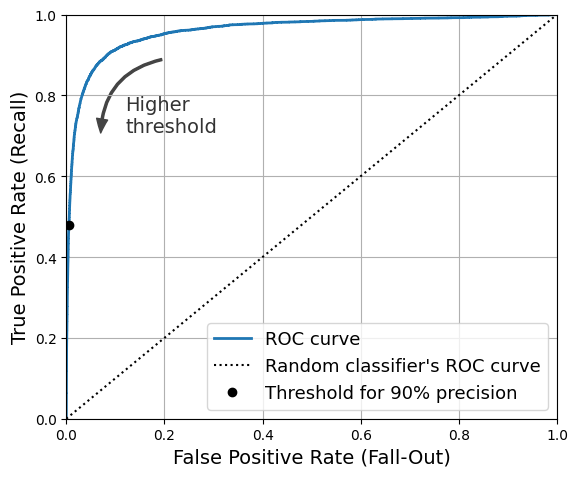

In [65]:
# 绘制FPR和TPR的对比图，找到对应与90%精确率的阈值的索引，由于阈值是降序排序，所以用<=而不是>=
idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

plt.figure(figsize=(6, 5))  # extra code – not needed, just formatting
plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")
plt.plot([fpr_90], [tpr_90], "ko", label="Threshold for 90% precision")

# extra code – just beautifies and saves Figure 3–7
plt.gca().add_patch(patches.FancyArrowPatch(
    (0.20, 0.89), (0.07, 0.70),
    connectionstyle="arc3,rad=.4",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))
plt.text(0.12, 0.71, "Higher\nthreshold", color="#333333")
plt.xlabel('False Positive Rate (Fall-Out)')
plt.ylabel('True Positive Rate (Recall)')
plt.grid()
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower right", fontsize=13)
save_fig("roc_curve_plot")

plt.show()
# 虚线表示纯随机分类器的ROC曲线

可看出，TPR（召回率）越高，FPR越多，一个好的分类器会尽可能的远离虚线，会尽可能的靠近左上角

比较分类器的方法是测量曲线下的面积（Area Under the Curve, AUC）。完美的分类器的ROC AUC等于1，而纯随机分类器的ROC AUC等于0.5。`Scikit-Learn`提供了估计ROC AUC的函数`roc_auc_score()`

In [66]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_train_5, y_scores)

np.float64(0.9604938554008616)

当看到ROC和AUC时，可能会认为这是一个很好的分类器了，但是在该例中阳性样本（5）相对于阴性样本（非5）是相当少的，但看到PR曲线时，发现还是有很大的改进空间（曲线可以更靠近右上角）。

如何觉得使用ROC曲线和PR曲线？
* 根据经验，只要**阳性类很少，或任务更关心假阳性而不是假阴性时**，更应使用PR曲线
* 否则，使用ROC曲线